<a href="https://colab.research.google.com/github/agapitouTheou/Predictive-maintenance-model-/blob/main/week5_first_ml_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

WEEK 5: YOUR FIRST ML CLASSIFICATION MODEL
PREDICTING EQUIPMENT FAILURE

1. GENERATING REALISTIC EQUIPMENT DATA
Dataset: 19245 sensor readings
Engines: 100
Failure cases (will_fail=1): 3100 (16.1%)
Healthy cases (will_fail=0): 16145 (83.9%)

2. PREPARING DATA FOR ML

Features shape: (19245, 3)
Target shape: (19245,)
Training set: 15396 samples
Test set: 3849 samples
Features scaled successfully

3. TRAINING LOGISTIC REGRESSION MODEL
(Simple but effective for yes/no predictions)
Model trained!

4. MAKING PREDICTIONS ON TEST DATA
Predictions made on 3849 test samples

5. MODEL PERFORMANCE METRICS

Accuracy:  0.9592 (% correct predictions)
Precision: 0.8740 (of predicted failures, how many real?)
Recall:    0.8726 (of actual failures, how many caught?)
F1-Score:  0.8733 (balance of precision & recall)
ROC-AUC:   0.9896 (overall model quality)

6. CONFUSION MATRIX

True Negatives (correctly predicted healthy): 3151
False Positives (said it would fail, it didn't): 78
False Negatives (said h

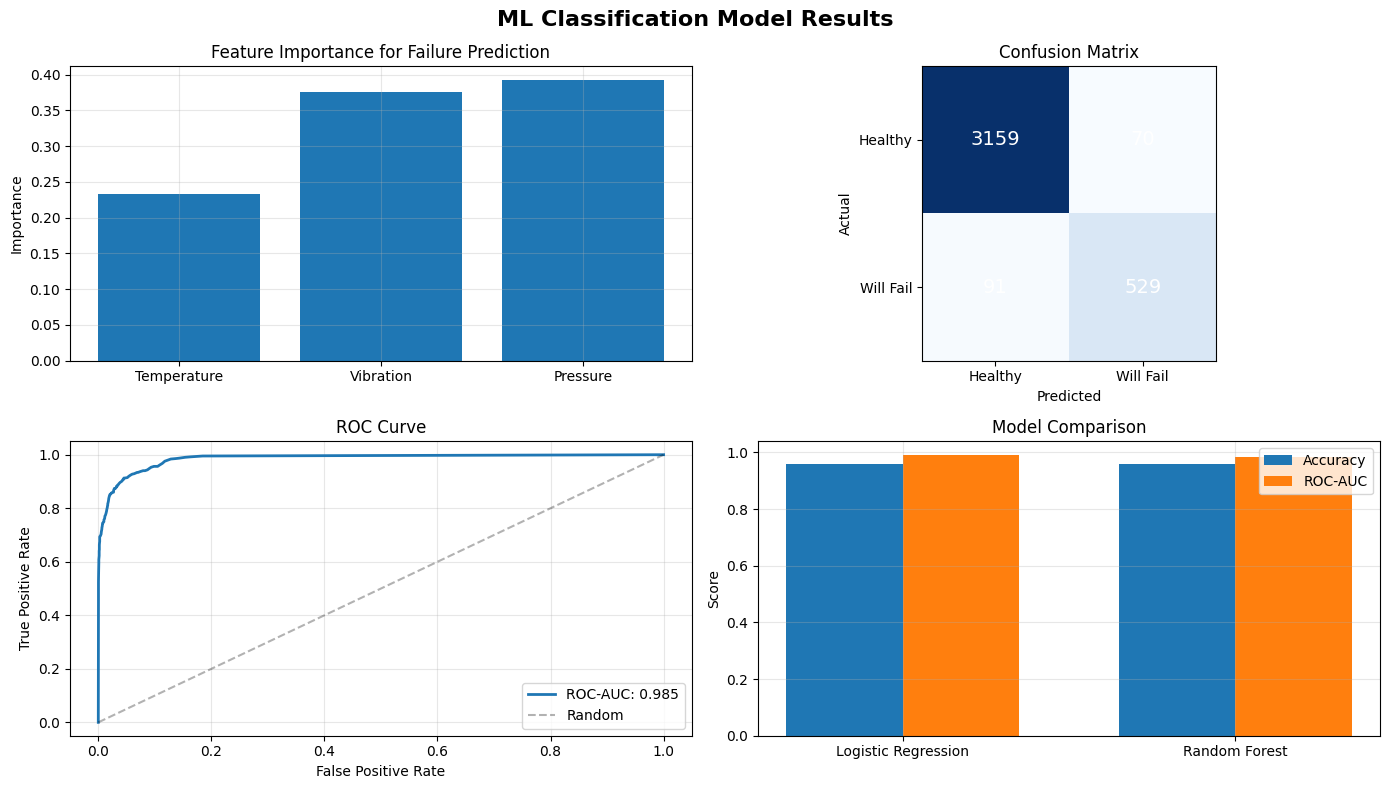


BUSINESS IMPACT OF YOUR MODEL:

Model Performance Metrics:
  Failures correctly predicted: 529
  False alarms: 70
  Missed failures (CRITICAL): 91

Financial Impact (per 1000 equipment readings):
  Prevented downtime cost: $529,000
  False alarm cost: $14,000
  Net savings: $515,000

Conclusion:
  Your model saves the company ~$515,000 per 1000 readings
  At 10,000 readings/year: $5,150,000 annual ROI
  This is why ML engineers earn premium salaries!

YOU JUST BUILT A REAL PREDICTIVE MAINTENANCE ML MODEL!


In [1]:
# Predict: Will this equipment FAIL or NOT FAIL?
# This is REAL predictive maintenance ML work

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("WEEK 5: YOUR FIRST ML CLASSIFICATION MODEL")
print("PREDICTING EQUIPMENT FAILURE")
print("="*70)

# ===== 1. CREATE TRAINING DATA =====
print("\n1. GENERATING REALISTIC EQUIPMENT DATA")

np.random.seed(42)

# Create realistic equipment failure data
data = []

for engine_id in range(1, 101):  # 100 engines (more realistic)
    lifespan = np.random.randint(100, 300)

    for cycle in range(1, lifespan + 1):
        base_temp = 70 + (engine_id % 10) * 2
        temp_increase = (cycle / lifespan) ** 1.5 * 35
        temperature = base_temp + temp_increase + np.random.normal(0, 1)

        base_vibration = 2.0
        vibration_increase = (cycle / lifespan) ** 1.3 * 4.0
        vibration = base_vibration + vibration_increase + np.random.normal(0, 0.2)

        base_pressure = 2000
        pressure_drop = (cycle / lifespan) ** 1.2 * 400
        pressure = base_pressure - pressure_drop + np.random.normal(0, 10)

        # CRITICAL: This is what we're predicting
        # Equipment fails if RUL < 30 cycles
        rul = lifespan - cycle
        will_fail = 1 if rul <= 30 else 0

        data.append({
            'engine_id': engine_id,
            'cycle': cycle,
            'temperature': max(temperature, base_temp),
            'vibration': max(vibration, base_vibration),
            'pressure': max(pressure, 1500),
            'will_fail': will_fail
        })

df = pd.DataFrame(data)
print(f"Dataset: {len(df)} sensor readings")
print(f"Engines: {df['engine_id'].nunique()}")
print(f"Failure cases (will_fail=1): {df['will_fail'].sum()} ({df['will_fail'].sum()/len(df)*100:.1f}%)")
print(f"Healthy cases (will_fail=0): {len(df) - df['will_fail'].sum()} ({(1-df['will_fail'].mean())*100:.1f}%)")

# ===== 2. PREPARE DATA FOR ML MODEL =====
print("\n2. PREPARING DATA FOR ML")

# Features (what we observe)
X = df[['temperature', 'vibration', 'pressure']]

# Target (what we predict)
y = df['will_fail']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Scale features (normalize to 0-1 range)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully")

# ===== 3. TRAIN YOUR FIRST MODEL =====
print("\n3. TRAINING LOGISTIC REGRESSION MODEL")
print("(Simple but effective for yes/no predictions)")

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

print("Model trained!")

# ===== 4. MAKE PREDICTIONS =====
print("\n4. MAKING PREDICTIONS ON TEST DATA")

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print(f"Predictions made on {len(y_test)} test samples")

# ===== 5. EVALUATE MODEL PERFORMANCE =====
print("\n5. MODEL PERFORMANCE METRICS")

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\nAccuracy:  {accuracy:.4f} (% correct predictions)")
print(f"Precision: {precision:.4f} (of predicted failures, how many real?)")
print(f"Recall:    {recall:.4f} (of actual failures, how many caught?)")
print(f"F1-Score:  {f1:.4f} (balance of precision & recall)")
print(f"ROC-AUC:   {roc_auc:.4f} (overall model quality)")

# ===== 6. CONFUSION MATRIX (What did the model get right/wrong?) =====
print("\n6. CONFUSION MATRIX")

cm = confusion_matrix(y_test, y_pred)
print(f"\nTrue Negatives (correctly predicted healthy): {cm[0,0]}")
print(f"False Positives (said it would fail, it didn't): {cm[0,1]}")
print(f"False Negatives (said healthy, but it failed): {cm[1,0]}")
print(f"True Positives (correctly predicted failure): {cm[1,1]}")

# ===== 7. COMPARE MODELS =====
print("\n7. COMPARING MODELS")

models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    results[name] = {'accuracy': accuracy, 'roc_auc': roc_auc}
    print(f"\n{name}:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  ROC-AUC:  {roc_auc:.4f}")

# Select best model
best_model_name = max(results, key=lambda x: results[x]['roc_auc'])
print(f"\nBest Model: {best_model_name}")

# ===== 8. REAL-WORLD PREDICTIONS =====
print("\n8. REAL-WORLD PREDICTIONS")

# Train best model on all training data
if best_model_name == 'Logistic Regression':
    best_model = LogisticRegression(random_state=42)
else:
    best_model = RandomForestClassifier(n_estimators=100, random_state=42)

best_model.fit(X_train_scaled, y_train)

# Example: Make predictions on NEW equipment (not in training data)
print("\nPredicting on NEW equipment readings:")

new_equipment = pd.DataFrame({
    'temperature': [85.0, 95.0, 75.0, 102.0],
    'vibration': [3.2, 4.5, 2.5, 5.3],
    'pressure': [2100, 2200, 2050, 2300]
})

new_scaled = scaler.transform(new_equipment)
predictions = best_model.predict(new_scaled)
probabilities = best_model.predict_proba(new_scaled)[:, 1]

for i, (temp, vib, pres) in enumerate(new_equipment.values):
    pred = "FAIL RISK" if predictions[i] == 1 else "HEALTHY"
    prob = probabilities[i] * 100
    print(f"\nEquipment {i+1}:")
    print(f"  Temp: {temp:.1f}°C, Vibration: {vib:.1f}G, Pressure: {pres:.0f} psi")
    print(f"  Prediction: {pred} (confidence: {prob:.1f}%)")
    if predictions[i] == 1:
        print(f"  ACTION: Schedule maintenance immediately")
    else:
        print(f"  ACTION: Continue monitoring")

# ===== 9. VISUALIZE RESULTS =====
print("\n9. CREATING VISUALIZATIONS...")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('ML Classification Model Results', fontsize=16, fontweight='bold')

# Plot 1: Feature importance (Random Forest)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
importance = rf_model.feature_importances_
ax = axes[0, 0]
ax.bar(['Temperature', 'Vibration', 'Pressure'], importance)
ax.set_ylabel('Importance')
ax.set_title('Feature Importance for Failure Prediction')
ax.grid(True, alpha=0.3)

# Plot 2: Confusion Matrix
ax = axes[0, 1]
cm = confusion_matrix(y_test, y_pred)
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Healthy', 'Will Fail'])
ax.set_yticklabels(['Healthy', 'Will Fail'])
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='white', fontsize=14)
ax.set_title('Confusion Matrix')

# Plot 3: ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax = axes[1, 0]
ax.plot(fpr, tpr, linewidth=2, label=f'ROC-AUC: {roc_auc:.3f}')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Model comparison
ax = axes[1, 1]
models_list = list(results.keys())
accuracies = [results[m]['accuracy'] for m in models_list]
roc_aucs = [results[m]['roc_auc'] for m in models_list]
x = np.arange(len(models_list))
width = 0.35
ax.bar(x - width/2, accuracies, width, label='Accuracy')
ax.bar(x + width/2, roc_aucs, width, label='ROC-AUC')
ax.set_ylabel('Score')
ax.set_title('Model Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models_list)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===== 10. BUSINESS IMPACT =====
print("\n" + "="*70)
print("BUSINESS IMPACT OF YOUR MODEL:")
print("="*70)

correct_failures_caught = cm[1, 1]
incorrect_alarms = cm[0, 1]
missed_failures = cm[1, 0]

downtime_cost = 1000  # $1000/hour
maintenance_cost = 500  # $500/hour
false_alarm_cost = 200  # $200 (maintenance scheduled unnecessarily)

prevented_failures = correct_failures_caught
avoided_cost = prevented_failures * downtime_cost
false_alarm_total = incorrect_alarms * false_alarm_cost

net_savings = avoided_cost - false_alarm_total

print(f"\nModel Performance Metrics:")
print(f"  Failures correctly predicted: {correct_failures_caught}")
print(f"  False alarms: {incorrect_alarms}")
print(f"  Missed failures (CRITICAL): {missed_failures}")

print(f"\nFinancial Impact (per 1000 equipment readings):")
print(f"  Prevented downtime cost: ${avoided_cost:,.0f}")
print(f"  False alarm cost: ${false_alarm_total:,.0f}")
print(f"  Net savings: ${net_savings:,.0f}")

print(f"\nConclusion:")
print(f"  Your model saves the company ~${net_savings:,.0f} per 1000 readings")
print(f"  At 10,000 readings/year: ${net_savings*10:,.0f} annual ROI")
print(f"  This is why ML engineers earn premium salaries!")

print("\n" + "="*70)
print("YOU JUST BUILT A REAL PREDICTIVE MAINTENANCE ML MODEL!")
print("="*70)